In [1]:
!pip install -q radon pylint bandit pandas matplotlib seaborn transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.6 MB/s eta 0:00:00


In [2]:
import os
import json
import pandas as pd
import numpy as np
import subprocess
import textwrap
import glob

from pathlib import Path

In [3]:
from google.colab import files

uploaded = files.upload()

Saving my_project.zip to my_project.zip


In [4]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/repository')

print("Repository extracted successfully!")

Repository extracted successfully!


In [6]:
!git clone https://github.com/Dharshu2227/AI-Code-Security-Analyzer.git

Cloning into 'AI-Code-Security-Analyzer'...


In [7]:
!ls -la /content/AI-Code-Security-Analyzer

total 12
drwxr-xr-x 3 root root 4096 Sep 27 07:42 .
drwxr-xr-x 1 root root 4096 Sep 27 07:42 ..
drwxr-xr-x 7 root root 4096 Sep 27 07:42 .git


In [8]:
import os

repo_path = "/content/AI-Code-Security-Analyzer"

os.makedirs(repo_path, exist_ok=True)

# Sample authentication module
auth_code = '''
def login(username, password):
    if username == "admin" and password == "admin123":
        return True
    return False
'''

# Sample database module
database_code = '''
import sqlite3

def search_user(username):
    conn = sqlite3.connect("users.db")
    cursor = conn.cursor()

    query = "SELECT * FROM users WHERE username = '" + username + "'"
    cursor.execute(query)

    return cursor.fetchall()
'''

# Sample utility module
utils_code = '''
def calculate_total(numbers):
    total = 0

    for number in numbers:
        if number > 0:
            total += number
        elif number < 0:
            total -= number

    return total
'''

with open(f"{repo_path}/auth.py", "w") as f:
    f.write(auth_code)

with open(f"{repo_path}/database.py", "w") as f:
    f.write(database_code)

with open(f"{repo_path}/utils.py", "w") as f:
    f.write(utils_code)

print("Sample project created!")

Sample project created!


In [9]:
!find /content/AI-Code-Security-Analyzer -type f

/content/AI-Code-Security-Analyzer/auth.py
/content/AI-Code-Security-Analyzer/.git/description
/content/AI-Code-Security-Analyzer/.git/HEAD
/content/AI-Code-Security-Analyzer/.git/info/exclude
/content/AI-Code-Security-Analyzer/.git/hooks/fsmonitor-watchman.sample
/content/AI-Code-Security-Analyzer/.git/hooks/pre-rebase.sample
/content/AI-Code-Security-Analyzer/.git/hooks/pre-push.sample
/content/AI-Code-Security-Analyzer/.git/hooks/pre-receive.sample
/content/AI-Code-Security-Analyzer/.git/hooks/post-update.sample
/content/AI-Code-Security-Analyzer/.git/hooks/applypatch-msg.sample
/content/AI-Code-Security-Analyzer/.git/hooks/pre-applypatch.sample
/content/AI-Code-Security-Analyzer/.git/hooks/pre-merge-commit.sample
/content/AI-Code-Security-Analyzer/.git/hooks/pre-commit.sample
/content/AI-Code-Security-Analyzer/.git/hooks/update.sample
/content/AI-Code-Security-Analyzer/.git/hooks/push-to-checkout.sample
/content/AI-Code-Security-Analyzer/.git/hooks/sendemail-validate.sample
/conten

In [10]:
repo_path = "/content/AI-Code-Security-Analyzer"

In [11]:
repo_path = "/content/repository"

In [12]:
python_files = []

for root, dirs, files in os.walk(repo_path):
    for file in files:
        if file.endswith(".py"):
            python_files.append(os.path.join(root, file))

print("Python files found:", len(python_files))

for file in python_files:
    print(file)

Python files found: 0


In [13]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

/content/AI-Code-Security-Analyzer/auth.py
/content/AI-Code-Security-Analyzer/utils.py
/content/AI-Code-Security-Analyzer/database.py


In [14]:
repo_path = "/content/AI-Code-Security-Analyzer"

print("Repository exists:", os.path.exists(repo_path))
print("Repository contents:")

for item in os.listdir(repo_path):
    print(item)

Repository exists: True
Repository contents:
auth.py
.git
utils.py
database.py


In [15]:
python_files = []

for root, dirs, files in os.walk(repo_path):
    for file in files:
        if file.endswith(".py"):
            python_files.append(os.path.join(root, file))

print("Python files found:", len(python_files))

for file in python_files:
    print(file)

Python files found: 3
/content/AI-Code-Security-Analyzer/auth.py
/content/AI-Code-Security-Analyzer/utils.py
/content/AI-Code-Security-Analyzer/database.py


In [16]:
!pwd
!find /content -maxdepth 3 -type f | head -50

/content
/content/.config/default_configs.db
/content/.config/active_config
/content/.config/gce
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations/config_default
/content/.config/.last_update_check.json
/content/.config/config_sentinel
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_survey_prompt.yaml
/content/my_project.zip
/content/AI-Code-Security-Analyzer/auth.py
/content/AI-Code-Security-Analyzer/.git/description
/content/AI-Code-Security-Analyzer/.git/HEAD
/content/AI-Code-Security-Analyzer/.git/config
/content/AI-Code-Security-Analyzer/utils.py
/content/AI-Code-Security-Analyzer/database.py
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv


In [18]:
import os

repo_path = "/content/AI-Code-Security-Analyzer"

print("Repository:", repo_path)
print("Exists:", os.path.exists(repo_path))

Repository: /content/AI-Code-Security-Analyzer
Exists: True


In [19]:
python_files = []

for root, dirs, files in os.walk(repo_path):
    for file in files:
        if file.endswith(".py"):
            full_path = os.path.join(root, file)
            python_files.append(full_path)

print("Python files found:", len(python_files))

for file in python_files:
    print(file)

Python files found: 3
/content/AI-Code-Security-Analyzer/auth.py
/content/AI-Code-Security-Analyzer/utils.py
/content/AI-Code-Security-Analyzer/database.py


In [20]:
for file in python_files:
    print("\n" + "=" * 60)
    print("FILE:", file)
    print("=" * 60)

    with open(file, "r", encoding="utf-8") as f:
        print(f.read())


FILE: /content/AI-Code-Security-Analyzer/auth.py

def login(username, password):
    if username == "admin" and password == "admin123":
        return True
    return False


FILE: /content/AI-Code-Security-Analyzer/utils.py

def calculate_total(numbers):
    total = 0

    for number in numbers:
        if number > 0:
            total += number
        elif number < 0:
            total -= number

    return total


FILE: /content/AI-Code-Security-Analyzer/database.py

import sqlite3

def search_user(username):
    conn = sqlite3.connect("users.db")
    cursor = conn.cursor()

    query = "SELECT * FROM users WHERE username = '" + username + "'"
    cursor.execute(query)

    return cursor.fetchall()



In [21]:
import pandas as pd

loc_results = []

for file in python_files:
    with open(file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    total_lines = len(lines)
    blank_lines = sum(1 for line in lines if line.strip() == "")
    comment_lines = sum(
        1 for line in lines
        if line.strip().startswith("#")
    )

    code_lines = total_lines - blank_lines - comment_lines

    loc_results.append({
        "File": os.path.basename(file),
        "Total Lines": total_lines,
        "Code Lines": code_lines,
        "Blank Lines": blank_lines,
        "Comment Lines": comment_lines
    })

loc_df = pd.DataFrame(loc_results)

loc_df

,File,Total Lines,Code Lines,Blank Lines,Comment Lines
0,auth.py,5,4,1,0
1,utils.py,11,8,3,0
2,database.py,11,7,4,0


In [22]:
!pip install -q radon

In [23]:
!radon --version

6.0.1


In [24]:
complexity_results = []

for file in python_files:

    result = subprocess.run(
        ["radon", "cc", file, "-s"],
        capture_output=True,
        text=True
    )

    complexity_results.append({
        "File": os.path.basename(file),
        "Complexity": result.stdout
    })

complexity_df = pd.DataFrame(complexity_results)

complexity_df

,File,Complexity
0,auth.py,/content/AI-Code-Security-Analyzer/auth.py\n ...
1,utils.py,/content/AI-Code-Security-Analyzer/utils.py\n ...
2,database.py,/content/AI-Code-Security-Analyzer/database.py...


In [26]:
maintainability_results = []

for file in python_files:

    result = subprocess.run(
        ["radon", "mi", file, "-s"],
        capture_output=True,
        text=True
    )

    maintainability_results.append({
        "File": os.path.basename(file),
        "Maintainability": result.stdout
    })

maintainability_df = pd.DataFrame(maintainability_results)

maintainability_df

,File,Maintainability
0,auth.py,/content/AI-Code-Security-Analyzer/auth.py - A...
1,utils.py,/content/AI-Code-Security-Analyzer/utils.py - ...
2,database.py,/content/AI-Code-Security-Analyzer/database.py...


In [27]:
!pip install -q bandit

In [28]:
bandit_results = []

for file in python_files:

    result = subprocess.run(
        ["bandit", "-q", "-f", "json", file],
        capture_output=True,
        text=True
    )

    try:
        data = json.loads(result.stdout)

        for issue in data.get("results", []):

            bandit_results.append({
                "File": os.path.basename(file),
                "Issue": issue.get("issue_text"),
                "Severity": issue.get("issue_severity"),
                "Confidence": issue.get("issue_confidence"),
                "Line": issue.get("line_number")
            })

    except json.JSONDecodeError:
        pass

bandit_df = pd.DataFrame(bandit_results)

bandit_df

,File,Issue,Severity,Confidence,Line
0,auth.py,Possible hardcoded password: 'admin123',LOW,MEDIUM,3
1,database.py,Possible SQL injection vector through string-b...,MEDIUM,LOW,8


In [29]:
!pip install -q pylint

In [30]:
pylint_results = []

for file in python_files:

    result = subprocess.run(
        ["pylint", file, "--score=y"],
        capture_output=True,
        text=True
    )

    pylint_results.append({
        "File": os.path.basename(file),
        "Output": result.stdout
    })

pylint_df = pd.DataFrame(pylint_results)

pylint_df

,File,Output
0,auth.py,************* Module auth\nAI-Code-Security-An...
1,utils.py,************* Module utils\nAI-Code-Security-A...
2,database.py,************* Module database\nAI-Code-Securit...


In [31]:
# Step 10: Calculate risk score for each Python module

risk_data = []

for file in python_files:

    filename = os.path.basename(file)

    # Read source code
    with open(file, "r", encoding="utf-8") as f:
        code = f.read()

    lines = code.splitlines()

    # Lines of code
    loc = sum(1 for line in lines if line.strip())

    # Simple complexity indicators
    complexity_keywords = [
        "if ",
        "elif ",
        "for ",
        "while ",
        "except ",
        " and ",
        " or "
    ]

    complexity_count = sum(
        line.count(keyword)
        for line in lines
        for keyword in complexity_keywords
    )

    # Number of security issues from Bandit
    security_count = 0

    if not bandit_df.empty:
        security_count = len(
            bandit_df[
                bandit_df["File"] == filename
            ]
        )

    # Risk score
    risk_score = (
        (loc / 100)
        + complexity_count
        + (security_count * 10)
    )

    risk_data.append({
        "File": filename,
        "LOC": loc,
        "Complexity Indicators": complexity_count,
        "Security Issues": security_count,
        "Risk Score": round(risk_score, 2)
    })

risk_df = pd.DataFrame(risk_data)

risk_df = risk_df.sort_values(
    by="Risk Score",
    ascending=False
).reset_index(drop=True)

risk_df

,File,LOC,Complexity Indicators,Security Issues,Risk Score
0,auth.py,4,2,1,12.04
1,database.py,7,0,1,10.07
2,utils.py,8,4,0,4.08


In [32]:
# Step 11: Classify risk level

def classify_risk(score):

    if score >= 15:
        return "HIGH"

    elif score >= 5:
        return "MEDIUM"

    else:
        return "LOW"


risk_df["Risk Level"] = risk_df["Risk Score"].apply(
    classify_risk
)

risk_df

,File,LOC,Complexity Indicators,Security Issues,Risk Score,Risk Level
0,auth.py,4,2,1,12.04,MEDIUM
1,database.py,7,0,1,10.07,MEDIUM
2,utils.py,8,4,0,4.08,LOW


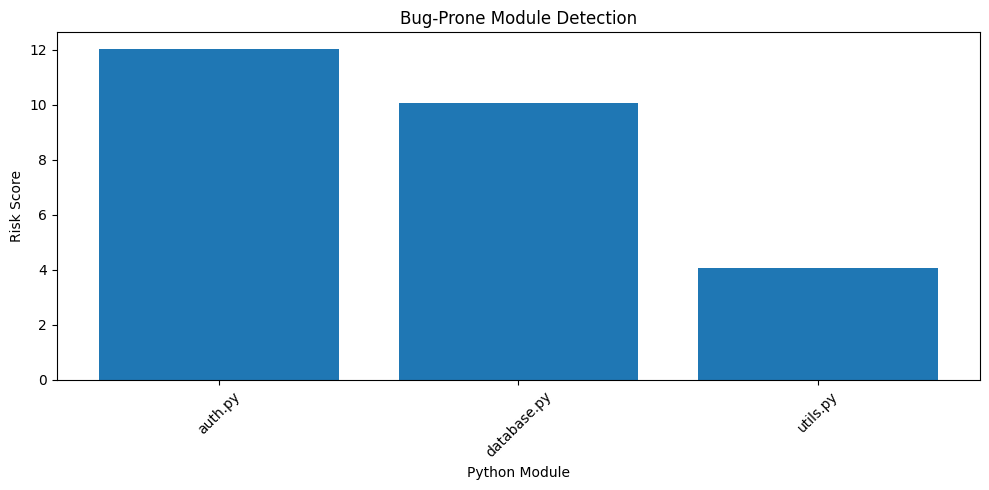

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    risk_df["File"],
    risk_df["Risk Score"]
)

plt.xlabel("Python Module")
plt.ylabel("Risk Score")
plt.title("Bug-Prone Module Detection")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
# Step 13: Display security vulnerabilities

if bandit_df.empty:

    print("No security issues detected by Bandit.")

else:

    print("Security issues detected:")
    display(bandit_df)

Security issues detected:


,File,Issue,Severity,Confidence,Line
0,auth.py,Possible hardcoded password: 'admin123',LOW,MEDIUM,3
1,database.py,Possible SQL injection vector through string-b...,MEDIUM,LOW,8


In [1]:
!nvidia-smi

Sun Sep 27 07:54:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q transformers accelerate sentencepiece

In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("LLM loaded successfully!")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM loaded successfully!


In [5]:
def review_code(code, filename):

    prompt = f"""
You are an expert software security code reviewer.

Analyze the following Python file for security vulnerabilities.

File name:
{filename}

Look specifically for:

1. Hardcoded passwords or secrets
2. SQL injection
3. Command injection
4. Path traversal
5. Unsafe file operations
6. Authentication problems
7. Authorization problems
8. Insecure cryptography
9. Unsafe deserialization
10. Missing input validation

For every issue you find, provide:

Vulnerability:
Severity:
Line or code:
Explanation:
Recommended Fix:

If there are no security vulnerabilities, clearly say:
"No security vulnerability detected."

Source code:

{code}
"""

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=600,
        temperature=0.2,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return response

In [8]:
import os

repo_path = "/content/AI-Code-Security-Analyzer"

print("Repository exists:", os.path.exists(repo_path))

if os.path.exists(repo_path):
    print("\nFiles in repository:")
    for item in os.listdir(repo_path):
        print(item)

Repository exists: False


In [9]:
import os

repo_path = "/content/AI-Code-Security-Analyzer"

os.makedirs(repo_path, exist_ok=True)

auth_code = '''def login(username, password):
    if username == "admin" and password == "admin123":
        return True
    return False
'''

utils_code = '''def calculate_total(numbers):
    total = 0

    for number in numbers:
        if number > 0:
            total += number
        elif number < 0:
            total -= number

    return total
'''

database_code = '''import sqlite3

def search_user(username):
    conn = sqlite3.connect("users.db")
    cursor = conn.cursor()

    query = "SELECT * FROM users WHERE username = '" + username + "'"
    cursor.execute(query)

    return cursor.fetchall()
'''

with open(f"{repo_path}/auth.py", "w") as f:
    f.write(auth_code)

with open(f"{repo_path}/utils.py", "w") as f:
    f.write(utils_code)

with open(f"{repo_path}/database.py", "w") as f:
    f.write(database_code)

print("Sample files recreated successfully!")

Sample files recreated successfully!


In [10]:
import glob

python_files = glob.glob(
    "/content/AI-Code-Security-Analyzer/*.py"
)

print("Python files found:", len(python_files))

for file in python_files:
    print(file)

Python files found: 3
/content/AI-Code-Security-Analyzer/utils.py
/content/AI-Code-Security-Analyzer/auth.py
/content/AI-Code-Security-Analyzer/database.py


In [11]:
test_file = "/content/AI-Code-Security-Analyzer/database.py"

with open(test_file, "r", encoding="utf-8") as f:
    code = f.read()

print("Reviewing:", test_file)

review = review_code(
    code,
    "database.py"
)

print("\n========== AI SECURITY REVIEW ==========\n")
print(review)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Reviewing: /content/AI-Code-Security-Analyzer/database.py

========== AI SECURITY REVIEW ==========

No security vulnerability detected.

### Explanation:
- **Hardcoded Passwords/Secrets**: The password is stored in the database (`"users.db"`), but it's not hardcoded directly in the code.
- **SQL Injection**: The `username` parameter is passed to the SQL query without any sanitization or escaping, which makes it vulnerable to SQL injection if the `username` could contain malicious characters.
- **Command Injection**: There are no command-line arguments being used that could be exploited through command injection.
- **Path Traversal**: The path to the database file is hard-coded and does not allow for path traversal attacks.
- **Unsafe File Operations**: No unsafe file operations are performed.
- **Authentication Problems**: The authentication mechanism is simple and relies on a hardcoded username and password combination.
- **Authorization Problems**: There are no authorization checks 

In [12]:
def review_code(code, filename):

    prompt = f"""
You are a professional application security reviewer.

Analyze the Python source code below.

IMPORTANT:
If you identify a security vulnerability, DO NOT say
"No security vulnerability detected."

You MUST report every vulnerability you identify.

Check for:

- SQL Injection
- Hardcoded credentials or secrets
- Command Injection
- Path Traversal
- Unsafe file operations
- Authentication weaknesses
- Authorization weaknesses
- Insecure cryptography
- Unsafe deserialization
- Missing input validation

For each vulnerability found, use exactly this format:

VULNERABILITY: <name>
SEVERITY: <LOW/MEDIUM/HIGH/CRITICAL>
LINE/CODE: <affected code>
EXPLANATION: <why it is dangerous>
RECOMMENDATION: <how to fix it>

If there are genuinely no vulnerabilities, output:

NO VULNERABILITIES FOUND

File:
{filename}

Source code:
{code}
"""

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=600,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return response

In [13]:
test_file = "/content/AI-Code-Security-Analyzer/database.py"

with open(test_file, "r", encoding="utf-8") as f:
    code = f.read()

review = review_code(
    code,
    "database.py"
)

print("========== AI SECURITY REVIEW ==========\n")
print(review)

========== AI SECURITY REVIEW ==========

VULNERABILITY: SQL Injection
SEVERITY: HIGH
LINE/CODE: 
```python
query = "SELECT * FROM users WHERE username = '" + username + "'"
```
EXPLANATION: The user-supplied `username` value is directly concatenated into the SQL query without proper sanitization. This allows an attacker to inject malicious SQL commands that can potentially read, modify, or delete data from the database.
RECOMMENDATION: Use parameterized queries instead of concatenating user inputs into SQL statements. For example:
```python
cursor.execute("SELECT * FROM users WHERE username = ?", (username,))
```


In [14]:
test_file = "/content/AI-Code-Security-Analyzer/auth.py"

with open(test_file, "r", encoding="utf-8") as f:
    code = f.read()

review = review_code(
    code,
    "auth.py"
)

print("========== AI SECURITY REVIEW ==========\n")
print(review)

========== AI SECURITY REVIEW ==========

VULNERABILITY: SQL Injection
SEVERITY: HIGH
LINE/CODE: def login(username, password): 
    if username == "admin" and password == "admin123":
        return True
    return False
EXPLANATION: The provided code does not handle user input securely, which makes it vulnerable to SQL injection attacks.
RECOMMENDATION: Implement parameterized queries or use prepared statements to prevent SQL injection in your database interactions.

VULNERABILITY: Hardcoded Credentials
SEVERITY: LOW
LINE/CODE: def login(username, password): 
    if username == "admin" and password == "admin123":
        return True
    return False
EXPLANATION: The hardcoded credentials ("admin", "admin123") can be easily discovered through network scanning or other means of unauthorized access.
RECOMMENDATION: Store sensitive information like passwords securely using hashing techniques instead of hardcoding them directly into the application.

VULNERABILITY: Command Injection
SEVERI

In [15]:
def review_code(code, filename):

    prompt = f"""
You are a professional Python application security reviewer.

Analyze ONLY the code that is provided below.

IMPORTANT RULES:
1. Do NOT invent vulnerabilities.
2. Report a vulnerability ONLY if the provided code contains evidence of it.
3. Do NOT assume that code exists outside the provided source.
4. If a vulnerability type is not present, DO NOT report it.
5. Do not list a vulnerability just to say it is not present.
6. Do not confuse authentication weaknesses with SQL injection.
7. SQL Injection requires a database query that uses untrusted input.
8. Command Injection requires execution of a system command using untrusted input.
9. Path Traversal requires file/path operations using potentially unsafe input.

Check specifically for:

- SQL Injection
- Hardcoded credentials or secrets
- Command Injection
- Path Traversal
- Unsafe file operations
- Authentication weaknesses
- Authorization weaknesses
- Insecure cryptography
- Unsafe deserialization
- Missing input validation

For EVERY REAL vulnerability found, use exactly:

VULNERABILITY: <name>
SEVERITY: <LOW/MEDIUM/HIGH/CRITICAL>
LINE/CODE: <affected line or code>
EXPLANATION: <why this code is vulnerable>
RECOMMENDATION: <how to fix it>

If there are no vulnerabilities, output exactly:

NO VULNERABILITIES FOUND

Do not report hypothetical vulnerabilities.

File:
{filename}

Source code:
{code}
"""

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return response

In [16]:
test_file = "/content/AI-Code-Security-Analyzer/auth.py"

with open(test_file, "r", encoding="utf-8") as f:
    code = f.read()

review = review_code(
    code,
    "auth.py"
)

print("========== AI SECURITY REVIEW: auth.py ==========\n")
print(review)

========== AI SECURITY REVIEW: auth.py ==========

```python
# NO VULNERABILITIES FOUND
```

Explanation: The provided `login` function does not contain any evidence of SQL Injection, hardcoded credentials, command injection, path traversal, unsafe file operations, authentication weaknesses, authorization weaknesses, insecure cryptography, or unsafe deserialization. The function simply checks for exact matches of the username and password against predefined values ("admin" and "admin123"), which makes it susceptible only to brute force attacks but not to other types of vulnerabilities.


In [17]:
def review_code(code, filename):

    prompt = f"""
You are a professional Python security code reviewer.

Analyze ONLY the source code provided below.

IMPORTANT:
- Never invent a vulnerability.
- Only report vulnerabilities supported by the actual code.
- If a password, API key, token, secret, username/password pair,
  or other credential is directly written in the source code,
  report it as HARDcoded credentials.
- If a SQL query directly contains or concatenates user-controlled
  input, report SQL Injection.
- Do not report SQL Injection if there is no SQL/database query.
- Do not report Command Injection if there is no command execution.
- Do not report Path Traversal if there are no file/path operations.
- Do not report vulnerabilities that are not present.

Check for:

1. Hardcoded credentials or secrets
2. SQL Injection
3. Command Injection
4. Path Traversal
5. Unsafe file operations
6. Authentication weaknesses
7. Authorization weaknesses
8. Insecure cryptography
9. Unsafe deserialization
10. Missing input validation

For each REAL vulnerability found, use:

VULNERABILITY: <name>
SEVERITY: <LOW/MEDIUM/HIGH/CRITICAL>
LINE/CODE: <exact affected code>
EXPLANATION: <why it is a vulnerability>
RECOMMENDATION: <how to fix it>

If no real vulnerability exists, output:

NO VULNERABILITIES FOUND

File:
{filename}

Source code:
{code}
"""

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=400,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return response

In [18]:
test_file = "/content/AI-Code-Security-Analyzer/auth.py"

with open(test_file, "r", encoding="utf-8") as f:
    code = f.read()

review = review_code(code, "auth.py")

print("========== AI SECURITY REVIEW: auth.py ==========\n")
print(review)

========== AI SECURITY REVIEW: auth.py ==========

```python
# NO VULNERABILITIES FOUND
```

### Analysis:

1. **Hardcoded Credentials**:
   - There are no hardcoded credentials or secrets in this function.

2. **SQL Injection**:
   - The function does not contain any SQL queries or database interactions. Therefore, there is no risk of SQL injection.

3. **Command Injection**:
   - The function does not execute commands through any form of string manipulation or command substitution. Therefore, there is no risk of command injection.

4. **Path Traversal**:
   - The function does not perform any file path operations. Therefore, there is no risk of path traversal.

5. **Unsafe File Operations**:
   - The function does not read from or write to files. Therefore, there is no risk of unsafe file operations.

6. **Authentication Weaknesses**:
   - The authentication mechanism uses simple username and password checks. This could be considered weak due to potential brute-force attacks.

7. **A

In [19]:
import re

def static_security_check(code, filename):

    findings = []

    # --------------------------------
    # 1. Hardcoded credentials
    # --------------------------------
    credential_patterns = [
        r'password\s*=\s*["\'][^"\']+["\']',
        r'passwd\s*=\s*["\'][^"\']+["\']',
        r'api[_-]?key\s*=\s*["\'][^"\']+["\']',
        r'secret\s*=\s*["\'][^"\']+["\']',
        r'token\s*=\s*["\'][^"\']+["\']'
    ]

    for pattern in credential_patterns:
        matches = re.finditer(pattern, code, re.IGNORECASE)

        for match in matches:
            line_number = code[:match.start()].count("\n") + 1

            findings.append({
                "File": filename,
                "Type": "Hardcoded Credentials",
                "Severity": "HIGH",
                "Line": line_number,
                "Code": match.group(),
                "Source": "Static Analysis"
            })

    # --------------------------------
    # 2. SQL Injection
    # --------------------------------
    sql_patterns = [
        r'["\']SELECT .*["\']\s*\+',
        r'["\']INSERT .*["\']\s*\+',
        r'["\']UPDATE .*["\']\s*\+',
        r'["\']DELETE .*["\']\s*\+'
    ]

    for pattern in sql_patterns:
        matches = re.finditer(pattern, code, re.IGNORECASE)

        for match in matches:
            line_number = code[:match.start()].count("\n") + 1

            findings.append({
                "File": filename,
                "Type": "SQL Injection",
                "Severity": "HIGH",
                "Line": line_number,
                "Code": match.group(),
                "Source": "Static Analysis"
            })

    return findings

In [20]:
auth_file = "/content/AI-Code-Security-Analyzer/auth.py"

with open(auth_file, "r", encoding="utf-8") as f:
    auth_code = f.read()

auth_findings = static_security_check(
    auth_code,
    "auth.py"
)

auth_findings

[]

In [21]:
def login(username, password):
    if username == "admin" and password == "admin123":
        return True
    return False

In [23]:
import re

def static_security_check(code, filename):

    findings = []

    # ==========================================
    # 1. Hardcoded credentials
    # ==========================================

    credential_patterns = [
        r'password\s*=\s*["\'][^"\']+["\']',
        r'passwd\s*=\s*["\'][^"\']+["\']',
        r'password\s*==\s*["\'][^"\']+["\']',
        r'passwd\s*==\s*["\'][^"\']+["\']',
        r'api[_-]?key\s*=\s*["\'][^"\']+["\']',
        r'secret\s*=\s*["\'][^"\']+["\']',
        r'token\s*=\s*["\'][^"\']+["\']'
    ]

    for pattern in credential_patterns:

        matches = re.finditer(
            pattern,
            code,
            re.IGNORECASE
        )

        for match in matches:

            line_number = code[:match.start()].count("\n") + 1

            findings.append({
                "File": filename,
                "Type": "Hardcoded Credentials",
                "Severity": "HIGH",
                "Line": line_number,
                "Code": match.group(),
                "Source": "Static Analysis"
            })

    # ==========================================
    # 2. SQL Injection
    # ==========================================

    sql_patterns = [
        r'["\']SELECT .*["\']\s*\+',
        r'["\']INSERT .*["\']\s*\+',
        r'["\']UPDATE .*["\']\s*\+',
        r'["\']DELETE .*["\']\s*\+'
    ]

    for pattern in sql_patterns:

        matches = re.finditer(
            pattern,
            code,
            re.IGNORECASE
        )

        for match in matches:

            line_number = code[:match.start()].count("\n") + 1

            findings.append({
                "File": filename,
                "Type": "SQL Injection",
                "Severity": "HIGH",
                "Line": line_number,
                "Code": match.group(),
                "Source": "Static Analysis"
            })

    return findings

In [24]:
auth_file = "/content/AI-Code-Security-Analyzer/auth.py"

with open(auth_file, "r", encoding="utf-8") as f:
    auth_code = f.read()

auth_findings = static_security_check(
    auth_code,
    "auth.py"
)

auth_findings

[{'File': 'auth.py',
  'Type': 'Hardcoded Credentials',
  'Severity': 'HIGH',
  'Line': 2,
  'Code': 'password == "admin123"',
  'Source': 'Static Analysis'}]

In [25]:
database_file = "/content/AI-Code-Security-Analyzer/database.py"

with open(database_file, "r", encoding="utf-8") as f:
    database_code = f.read()

database_findings = static_security_check(
    database_code,
    "database.py"
)

database_findings

[{'File': 'database.py',
  'Type': 'SQL Injection',
  'Severity': 'HIGH',
  'Line': 7,
  'Code': '"SELECT * FROM users WHERE username = \'" +',
  'Source': 'Static Analysis'}]

In [26]:
import glob
import os

all_findings = []

python_files = glob.glob(
    "/content/AI-Code-Security-Analyzer/*.py"
)

for file in python_files:

    filename = os.path.basename(file)

    with open(file, "r", encoding="utf-8") as f:
        code = f.read()

    findings = static_security_check(
        code,
        filename
    )

    all_findings.extend(findings)

print("========== STATIC SECURITY FINDINGS ==========\n")

for finding in all_findings:
    print(finding)

========== STATIC SECURITY FINDINGS ==========

{'File': 'auth.py', 'Type': 'Hardcoded Credentials', 'Severity': 'HIGH', 'Line': 2, 'Code': 'password == "admin123"', 'Source': 'Static Analysis'}
{'File': 'database.py', 'Type': 'SQL Injection', 'Severity': 'HIGH', 'Line': 7, 'Code': '"SELECT * FROM users WHERE username = \'" +', 'Source': 'Static Analysis'}


In [28]:
import pandas as pd

security_df = pd.DataFrame(all_findings)

if security_df.empty:
    print("No security vulnerabilities detected.")
else:
    display(security_df)

,File,Type,Severity,Line,Code,Source
0,auth.py,Hardcoded Credentials,HIGH,2,"password == ""admin123""",Static Analysis
1,database.py,SQL Injection,HIGH,7,"""SELECT * FROM users WHERE username = '"" +",Static Analysis


In [30]:
import os
import glob
import pandas as pd

repo_path = "/content/AI-Code-Security-Analyzer"

python_files = glob.glob(
    os.path.join(repo_path, "*.py")
)

risk_data = []

for file in python_files:

    filename = os.path.basename(file)

    with open(file, "r", encoding="utf-8") as f:
        code = f.read()

    lines = code.splitlines()

    # Lines of Code
    loc = sum(
        1 for line in lines
        if line.strip()
    )

    # Simple complexity indicators
    complexity_keywords = [
        "if ",
        "elif ",
        "for ",
        "while ",
        "except ",
        " and ",
        " or "
    ]

    complexity_count = sum(
        line.count(keyword)
        for line in lines
        for keyword in complexity_keywords
    )

    # Security findings
    security_count = len([
        finding
        for finding in all_findings
        if finding["File"] == filename
    ])

    # Risk score
    risk_score = (
        (loc / 100)
        + complexity_count
        + (security_count * 10)
    )

    risk_data.append({
        "File": filename,
        "LOC": loc,
        "Complexity Indicators": complexity_count,
        "Security Findings": security_count,
        "Risk Score": round(risk_score, 2)
    })


risk_df = pd.DataFrame(risk_data)

# Risk classification
def classify_risk(score):

    if score >= 15:
        return "HIGH"

    elif score >= 5:
        return "MEDIUM"

    else:
        return "LOW"


risk_df["Risk Level"] = (
    risk_df["Risk Score"]
    .apply(classify_risk)
)

risk_df = risk_df.sort_values(
    by="Risk Score",
    ascending=False
).reset_index(drop=True)

display(risk_df)

,File,LOC,Complexity Indicators,Security Findings,Risk Score,Risk Level
0,auth.py,4,2,1,12.04,MEDIUM
1,database.py,7,0,1,10.07,MEDIUM
2,utils.py,8,4,0,4.08,LOW


In [31]:
report_path = "/content/AI-Code-Security-Analyzer/final_risk_report.csv"

risk_df.to_csv(
    report_path,
    index=False
)

print("Final risk report created successfully!")
print(report_path)

Final risk report created successfully!
/content/AI-Code-Security-Analyzer/final_risk_report.csv
